In [1]:
import sys
import os
sys.path.append(os.path.join("..", "rl"))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from supply_chain_env import SupplyChainEnv

sns.set_style("whitegrid")

MODEL_PATH = os.path.join("..", "models", "ppo_supply_chain_agent.zip")
model = PPO.load(MODEL_PATH)
print("Loaded trained PPO model.")

Loaded trained PPO model.


In [3]:
def rule_based_policy(obs):
    inventory, demand, pending_restock, restock_countdown, supplier_delayed = obs
    if inventory < 80 and pending_restock == 0:
        return 0  
    elif demand > 0 and inventory > 0:
        return 1  
    else:
        return 2  

In [4]:
def trace_episode(policy_fn_or_model, is_model=False, max_steps=100):
    env = SupplyChainEnv(max_steps=max_steps)
    obs, _ = env.reset()

    inventory_history = [obs[0]]
    demand_history = [obs[1]]
    action_history = []
    reward_history = []
    cumulative_reward = [0]

    done = False
    while not done:
        if is_model:
            action, _ = policy_fn_or_model.predict(obs, deterministic=True)
        else:
            action = policy_fn_or_model(obs)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        inventory_history.append(obs[0])
        demand_history.append(obs[1])
        action_history.append(int(action))
        reward_history.append(reward)
        cumulative_reward.append(info["total_reward"])

    return {
        "inventory": inventory_history,
        "demand": demand_history,
        "actions": action_history,
        "rewards": reward_history,
        "cumulative_reward": cumulative_reward,
    }

ppo_trace = trace_episode(model, is_model=True)
baseline_trace = trace_episode(rule_based_policy, is_model=False)

print(f"PPO final cumulative reward: {ppo_trace['cumulative_reward'][-1]:.2f}")
print(f"Baseline final cumulative reward: {baseline_trace['cumulative_reward'][-1]:.2f}")

PPO final cumulative reward: 1770.98
Baseline final cumulative reward: 1522.19


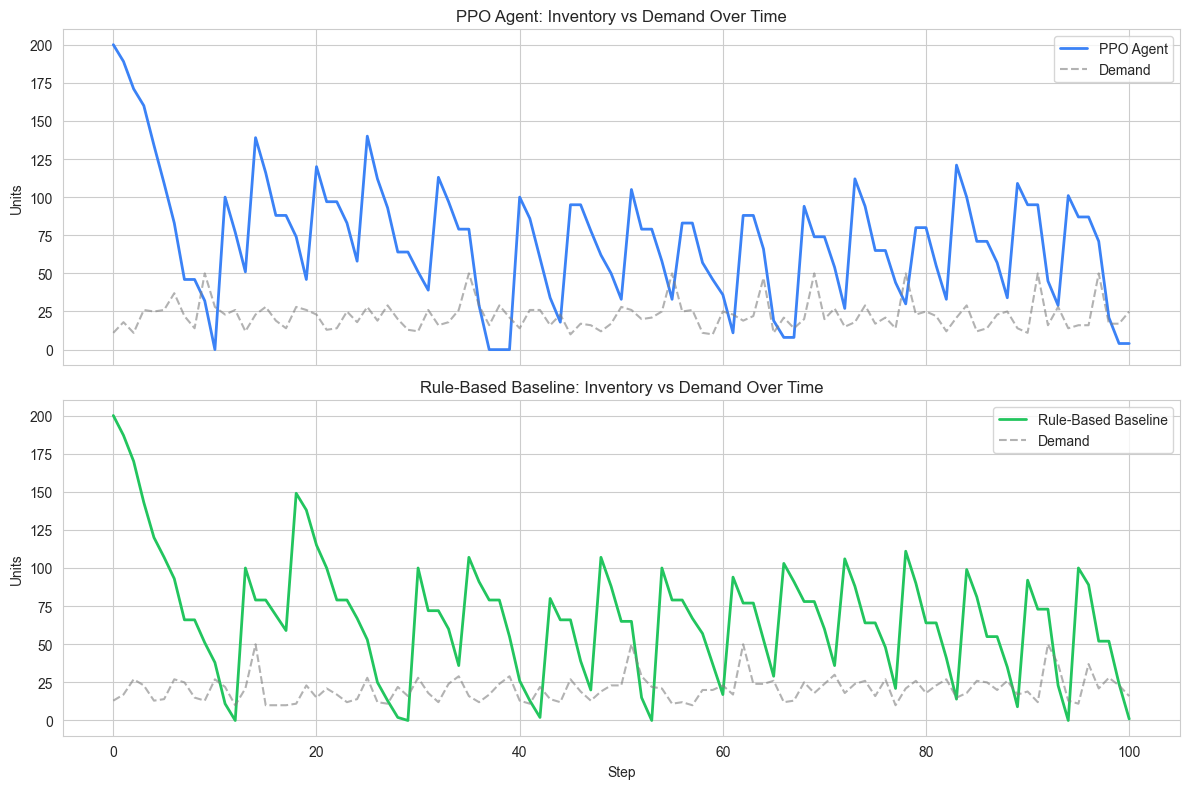

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(ppo_trace["inventory"], label="PPO Agent", color="#3B82F6", linewidth=2)
axes[0].plot(ppo_trace["demand"], label="Demand", color="gray", linestyle="--", alpha=0.6)
axes[0].set_title("PPO Agent: Inventory vs Demand Over Time")
axes[0].set_ylabel("Units")
axes[0].legend()

axes[1].plot(baseline_trace["inventory"], label="Rule-Based Baseline", color="#22C55E", linewidth=2)
axes[1].plot(baseline_trace["demand"], label="Demand", color="gray", linestyle="--", alpha=0.6)
axes[1].set_title("Rule-Based Baseline: Inventory vs Demand Over Time")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Units")
axes[1].legend()

plt.tight_layout()
plt.show()

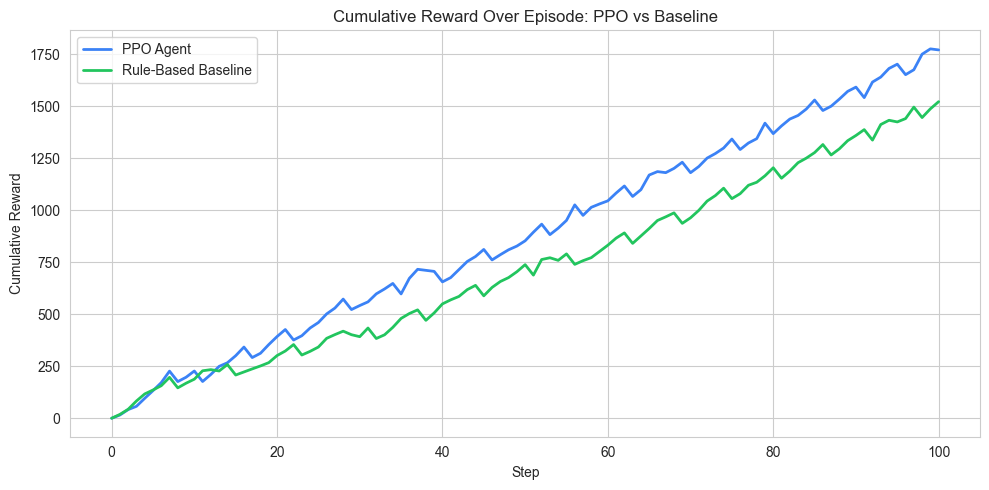

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(ppo_trace["cumulative_reward"], label="PPO Agent", color="#3B82F6", linewidth=2)
plt.plot(baseline_trace["cumulative_reward"], label="Rule-Based Baseline", color="#22C55E", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward Over Episode: PPO vs Baseline")
plt.legend()
plt.tight_layout()
plt.show()

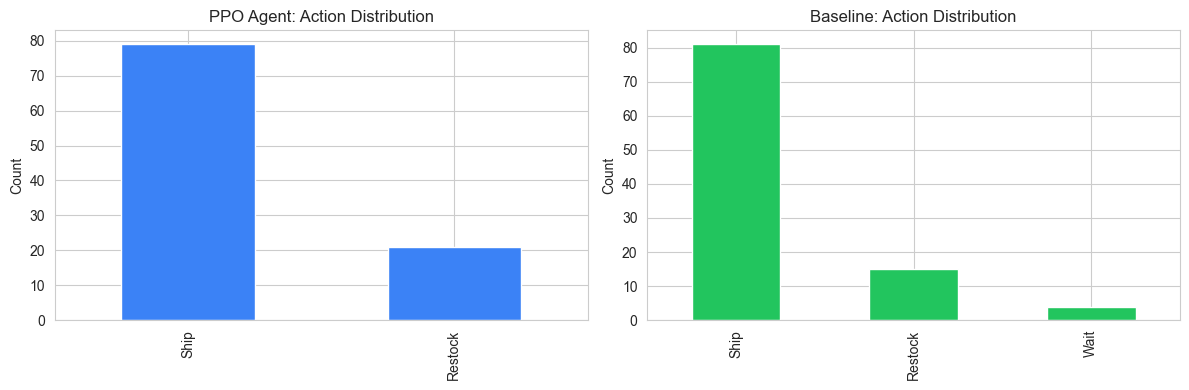

In [8]:
import pandas as pd
action_names = {0: "Restock", 1: "Ship", 2: "Wait", 3: "Reject"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ppo_action_counts = pd.Series(ppo_trace["actions"]).map(action_names).value_counts()
baseline_action_counts = pd.Series(baseline_trace["actions"]).map(action_names).value_counts()

ppo_action_counts.plot(kind="bar", ax=axes[0], color="#3B82F6")
axes[0].set_title("PPO Agent: Action Distribution")
axes[0].set_ylabel("Count")

baseline_action_counts.plot(kind="bar", ax=axes[1], color="#22C55E")
axes[1].set_title("Baseline: Action Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()